In [4]:
## change working directory to the root
import os
root_marker = 'setup.py'
current_dir = os.getcwd()
if not os.path.exists(os.path.join(current_dir, root_marker)):
    parent_dir = os.path.dirname(current_dir)
    os.chdir(parent_dir)
    # print(f"Working directory changed to: {os.getcwd()}")
# else:
    # print(f"Already at the root directory: {os.getcwd()}")
    
## import utility functions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tests.plot_all_utils import *

## simulation settings
import json
with open('tests/settings_time.json', 'r') as f:
    settings = json.load(f)
output_dir = settings['output_dir']
alp = settings['alp']
nsim = settings['nsim']
null_seed = settings['null_seed']
null_p = settings['null_p']
null_N = settings['null_N']
null_n = settings['null_n']
null_P = settings['null_P']
roc_seed = settings['roc_seed']
roc_p = null_p
roc_N = null_N
roc_n = null_n
roc_P = null_P
print(f"Output Directory: {output_dir}")
print(f"Number of Simulations: {nsim}")
print(f"NULL parameters: {null_p}, {null_N}, {null_n}, {null_P}")
print(f"ROC parameters: {roc_p}, {roc_N}, {roc_n}, {roc_P}")
os.makedirs(os.path.join(output_dir, 'res'), exist_ok=True)

## methods to test
methods_to_plot = 'all'
STTM_N = [10]
METHODS = [f'medtree_sttm_n{i}' for i in STTM_N]
if methods_to_plot == 'all':
    METHODS.extend(["CCIT", "RCIT", "GCM", "LPCIT"])
print(METHODS)

Output Directory: data/Aaa_time
Number of Simulations: 30
NULL parameters: 1, [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000], 800, []
ROC parameters: 1, [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000], 800, []
['medtree_sttm_n10', 'CCIT', 'RCIT', 'GCM', 'LPCIT']


In [5]:
viridis = plt.get_cmap("viridis")
to_hex = lambda rgba: '#{:02x}{:02x}{:02x}'.format(
    int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255)
)
levels = ["sttm_n5", "sttm_n10", "sttm_n15", "sttm_n20", "sttm_n25"]
viridis_colors = [to_hex(viridis(i)) for i in np.linspace(0, 1, len(levels))]
color_map = {
    f"medtree_{lvl}": col
    for lvl, col in zip(levels, viridis_colors)
}
color_map.update({
    "GCM":    "#117733",
    "wGCM":   "#44AA99",
    "CCIT":   "#88CCEE",
    "RCIT":   "#DDCC77",
    "CMIknn": "#CC6677",
    "LPCIT":  "#AA4499",
    "CDIT":   "#999933",
    "Extra":  "#882255",
})

## Simulation 1. Assessing Type 1 error rate control

Output Directory: data/Aaa_time2
Number of Simulations: 30
NULL parameters: 10, [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000], 800, []
ROC parameters: 10, [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000], 800, []
Error doing file 'data/Aaa_time2/null_n256000p10_CCIT_times.csv': data/Aaa_time2/null_n256000p10_CCIT_times.csv not found.
Error doing file 'data/Aaa_time2/null_n512000p10_CCIT_times.csv': data/Aaa_time2/null_n512000p10_CCIT_times.csv not found.
Error doing file 'data/Aaa_time2/null_n1024000p10_CCIT_times.csv': data/Aaa_time2/null_n1024000p10_CCIT_times.csv not found.
Output Directory: data/Aaa_time2
Number of Simulations: 30
NULL parameters: 100, [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000], 800, []
ROC parameters: 100, [1000, 2000, 4000, 8000, 16000, 32000, 64000, 128000, 256000, 512000, 1024000], 800, []
Error doing file 'data/Aaa_time2/null_n64000p100_CCIT_times.csv': data/Aaa_

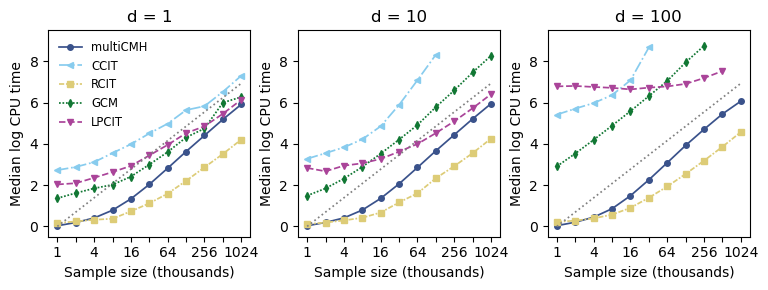

In [6]:
scale = 0.6
fig = plt.figure(figsize = (12.5*scale, 4.5*scale))
gs =gridspec.GridSpec(1,3)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[0,2])

prefix = 'null'
N = null_N
p = null_p
plot_time_lines(ax1, output_dir, prefix, N, p, "Median log CPU time", METHODS, nsim, color_map)

with open('tests/settings_time2.json', 'r') as f:
    settings = json.load(f)
output_dir = settings['output_dir']
alp = settings['alp']
nsim = settings['nsim']
null_seed = settings['null_seed']
null_p = 10
null_N = settings['null_N']
null_n = settings['null_n']
null_P = settings['null_P']
roc_seed = settings['roc_seed']
roc_p = null_p
roc_N = null_N
roc_n = null_n
roc_P = null_P
print(f"Output Directory: {output_dir}")
print(f"Number of Simulations: {nsim}")
print(f"NULL parameters: {null_p}, {null_N}, {null_n}, {null_P}")
print(f"ROC parameters: {roc_p}, {roc_N}, {roc_n}, {roc_P}")

prefix = 'null'
N = null_N
p = null_p
plot_time_lines(ax2, output_dir, prefix, N, p, "Median log CPU time", METHODS, nsim, color_map, legend=False)


with open('tests/settings_time2.json', 'r') as f:
    settings = json.load(f)
output_dir = settings['output_dir']
alp = settings['alp']
nsim = settings['nsim']
null_seed = settings['null_seed']
null_p = 100
null_N = settings['null_N']
null_n = settings['null_n']
null_P = settings['null_P']
roc_seed = settings['roc_seed']
roc_p = null_p
roc_N = null_N
roc_n = null_n
roc_P = null_P
print(f"Output Directory: {output_dir}")
print(f"Number of Simulations: {nsim}")
print(f"NULL parameters: {null_p}, {null_N}, {null_n}, {null_P}")
print(f"ROC parameters: {roc_p}, {roc_N}, {roc_n}, {roc_P}")

prefix = 'null'
N = null_N
p = null_p
plot_time_lines(ax3, output_dir, prefix, N, p, "Median log CPU time", METHODS, nsim, color_map, legend=False)

plt.tight_layout(pad=0, w_pad=-0.05, h_pad=0.5)
# plt.savefig(os.path.join(output_dir, 'res', prefix + f'_{os.path.basename(output_dir)}_{methods_to_plot}.pdf'))
plt.show()